In [1]:
from string import punctuation
from google.colab import drive
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import string
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import nltk
import re
nltk.download('omw-1.4')
from nltk.util import defaultdict
!pip install pyspellchecker
from spellchecker import SpellChecker
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline as SkPipeline

drive.mount('/content/drive')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 33.9 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Bath/NLP/cw_data.csv', header=None, names=['text', 'label'])

print(df.shape)
#print(df['text'].head(25))


print(f'Samples: {len(df)}   Classes: {df["label"].nunique()}')
print(df['label'].value_counts())

random = 63

SPELLING_FIXES = {
    r'\bacct\b': 'account',
    r'\baccts\b': 'accounts',
    r'\bpls\b': 'please',
    r'\bapplication\b': 'app',
    r'\bwat\b': 'what',
    r'\bemial\b': 'email',
    r'\b2\b': 'to',           #so 2fa unaffected
    r'\bw/out\b': 'without',
    r'\bw/\b': 'with',
    r'\bpwd\b': 'password',
    r'\bcant\b': 'cannot',
    r'\bwont\b': 'will not',
    r'\bdidnt\b':  'did not',
    r'\bdoesnt\b': 'does not',
    r'\bisnt\b':   'is not',
    r'\bwasnt\b':  'was not',
    r'\b(?:two|2)[\s-]*factor[\s-]*(?:authentication|auth)\b': '2fa', #regular expression
    r'\binfo\b': 'information'
}

def lowercase(texts):
  return [t.lower() for t in texts]

def remove_punctuation(texts):
    cleaned_texts = []
    for t in texts:
        t = re.sub(r'[^\w\s]', '', t)
        cleaned_texts.append(t)
    return cleaned_texts

def remove_hidden_characters(texts):
  cleaned_texts = []
  for t in texts:
    cleaned_texts.append(t.replace("\n", " ").replace("\t", " ").replace("\'", ''))
  return cleaned_texts

def whitespace_removal(texts):
  return [t.strip() for t in texts]

def tokenise(texts):
  tokenised_texts = []
  tokenised_texts = [word_tokenize(t) for t in texts]
  return tokenised_texts


def remove_stopwords(texts):
  cleaned_texts = []
  stop_words = list(stopwords.words('english'))
  for text in texts:
    cleaned_texts.append([w for w in text if not w in stop_words])
  return cleaned_texts

def stem_texts(texts):
  stemmer = PorterStemmer()
  return [[stemmer.stem(word) for word in text] for text in texts]

def lemmatise_texts(texts):
  lemmatiser = WordNetLemmatizer()
  return [[lemmatiser.lemmatize(word,pos='v') for word in text] for text in texts]

def preprocess(texts, reduction='s'):
    texts = lowercase(texts)

    # domain-specific typos
    cleaned_texts = []
    for text in texts:
        for pattern, replacement in SPELLING_FIXES.items():
            text = re.sub(pattern, replacement, text)
        cleaned_texts.append(text)
    texts = cleaned_texts

    texts = remove_punctuation(texts)
    texts = remove_hidden_characters(texts)
    texts = whitespace_removal(texts)

    texts = tokenise(texts)

    texts = remove_stopwords(texts)

    if reduction == 's':
        texts = stem_texts(texts)
    else:
        texts = lemmatise_texts(texts)

    return texts

X = df['text'].values #numpy array
y = df['label'].values


# stratify ensures each class is proportionally represented in both splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random, stratify=y)
print(type(X_train_raw)) #numpy array so acts likd a list of strings so is in exactly the form that we want

print(df['text'].iloc[25])
print(preprocess([df['text'].iloc[25]]))

(308, 2)
Samples: 308   Classes: 14
label
payment_issue              33
shipping_delay             29
notification_settings      24
delete_account             23
subscription_management    23
update_email               23
data_privacy               22
order_tracking             22
billing_history            21
account_recovery           21
refund_request             21
reset_password             20
login_issue                16
two_factor_auth            10
Name: count, dtype: int64
<class 'numpy.ndarray'>
how long refund show in acct?
[['long', 'refund', 'show', 'account']]


In [3]:
df['tokenised'] = preprocess(df['text'].tolist())
display(df[['text', 'tokenised','label']].sample(10, random_state=random))


all_tokens = [token for sublist in df['tokenised'] for token in sublist]
token_freq = Counter(all_tokens)

print(f'Vocabulary size: {len(token_freq)}')
print('\nTop 20 stems:')
for stem, freq in token_freq.most_common(20):
    print(f'  {stem:20s} {freq}')

,text,tokenised,label
267,download GDPR data copy — steps?,"[download, gdpr, data, copi, step]",data_privacy
254,how 2 delete my acct permanently?,"[delet, account, perman]",delete_account
128,Password reset: what steps should I follow on ...,"[password, reset, step, follow, new, laptop]",reset_password
295,I forgot my password — how can I recover acces...,"[forgot, password, recov, access, laptop]",reset_password
285,some credit card work some fail — why?,"[credit, card, work, fail]",payment_issue
8,access past bills France?,"[access, past, bill, franc]",billing_history
300,cant update emial if acct is locked wat do?,"[updat, email, account, lock]",update_email
10,failed payment affect acct status?,"[fail, payment, affect, account, statu]",payment_issue
42,where see billing history?,"[see, bill, histori]",billing_history
140,how 2 request refund?,"[request, refund]",refund_request


Vocabulary size: 284

Top 20 stems:
  account              60
  possibl              31
  email                30
  fail                 29
  delet                28
  payment              27
  subscript            25
  refund               25
  notif                24
  password             23
  track                21
  data                 21
  reset                21
  updat                18
  order                18
  chang                16
  bill                 16
  request              15
  step                 15
  ship                 14


Accuracy: 0.9354838709677419 (macro)
Precision: 0.9505952380952382 (macro)
Recall: 0.9166666666666667 (macro)
F1 Score: 0.9221603793032364 (macro)
                         precision    recall  f1-score   support

       account_recovery       1.00      1.00      1.00         4
        billing_history       1.00      0.75      0.86         4
           data_privacy       1.00      0.75      0.86         4
         delete_account       0.83      1.00      0.91         5
            login_issue       1.00      1.00      1.00         3
  notification_settings       1.00      1.00      1.00         5
         order_tracking       0.80      1.00      0.89         4
          payment_issue       0.88      1.00      0.93         7
         refund_request       1.00      1.00      1.00         4
         reset_password       0.80      1.00      0.89         4
         shipping_delay       1.00      0.83      0.91         6
subscription_management       1.00      1.00      1.00         5
       

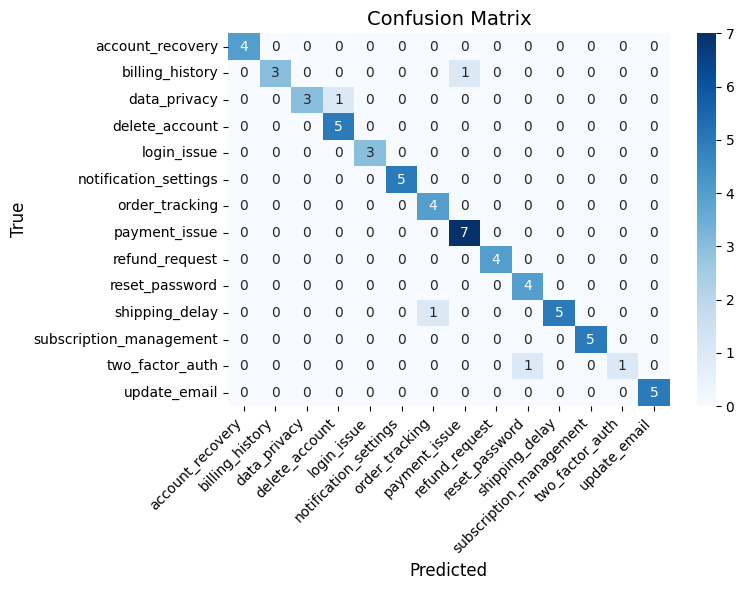

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


accuracy            : 0.8866  (±0.0349)
f1_macro            : 0.8693  (±0.0436)
precision_macro     : 0.9001  (±0.0414)
recall_macro        : 0.8688  (±0.0415)


In [4]:
X_train_stem = preprocess(X_train_raw)
X_test_stem = preprocess(X_test_raw)
#print(X_train_stem[0:4])

# already preprocessed and tokenised so make sure it doesnt do this
tfidf_vectoriser = TfidfVectorizer(
    ngram_range=(1,1),
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False
)

#this learns the vocabulary and the IDF values
X_train_stem_tfidf =tfidf_vectoriser.fit_transform(X_train_stem)

#this uses the vocabulary and IDF learned from the traini set
X_test_stem_tfidf = tfidf_vectoriser.transform(X_test_stem)

clf_tfidf = LogisticRegression(random_state=random).fit(X_train_stem_tfidf, y_train)
y_pred = clf_tfidf.predict(X_test_stem_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred)} (macro)")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')} (macro)")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')} (macro)")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')} (macro)")


print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

pipe = SkPipeline([
    ('tfidf', TfidfVectorizer(
    ngram_range=(1,1),
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False
)),
    ('clf',   LogisticRegression(random_state=random))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random)
cv  = cross_validate(pipe, preprocess(X), y, cv=skf,
                     scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'])


for m in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    s = cv[f'test_{m}']
    print(f'{m:20s}: {s.mean():.4f}  (±{s.std():.4f})')

In [6]:
mis = pd.DataFrame({
    'raw_text'  : X_test_raw,
    'tokenised' : X_test_stem,
    'true_label': y_test,
    'pred_label': y_pred
})

mis = mis[mis['true_label'] != mis['pred_label']]

print(f'Total Misclassified: {len(mis)} / {len(y_test)}')
display(mis.head(10))


feature_names = tfidf_vectoriser.get_feature_names_out()
print('Top 5 stem features per class:')

for i, cls in enumerate(clf_tfidf.classes_):
    top = clf_tfidf.coef_[i].argsort()[-5:][::-1]
    print(f'{cls:30s}: {[feature_names[j] for j in top]}')

Total Misclassified: 4 / 62


,raw_text,tokenised,true_label,pred_label
9,shipment marked delivered but not received!,"[shipment, mark, deliv, receiv]",shipping_delay,order_tracking
27,delete personal data without deleting acct?,"[delet, person, data, without, delet, account]",data_privacy,delete_account
34,How do I reset my two-factor authentication de...,"[reset, 2fa, devic]",two_factor_auth,reset_password
59,all subscription payments in history?,"[subscript, payment, histori]",billing_history,payment_issue


Top 5 stem features per class:
account_recovery              : ['recoveri', 'recov', 'account', 'help', 'email']
billing_history               : ['bill', 'histori', 'invoic', 'past', 'download']
data_privacy                  : ['data', 'person', 'request', 'access', 'restrict']
delete_account                : ['delet', 'account', 'remov', 'reactiv', 'step']
login_issue                   : ['login', 'log', 'cant', 'sign', 'unabl']
notification_settings         : ['notif', 'event', 'set', 'push', 'stop']
order_tracking                : ['track', 'order', 'mark', 'deliv', 'shipment']
payment_issue                 : ['payment', 'card', 'work', 'bank', 'transfer']
refund_request                : ['refund', 'request', 'long', 'get', 'method']
reset_password                : ['password', 'reset', 'tablet', 'forgot', 'follow']
shipping_delay                : ['ship', 'deliveri', 'delay', 'order', 'packag']
subscription_management       : ['subscript', 'plan', 'paus', 'cancel', 'temporarili']
t